# Cluster-Enhanced Severity Prediction

## Objective
Test whether the K-Means crash-archetype assignment improves supervised accident-severity prediction.

We compare the same models with:
- 136 existing Information-Gain-selected features
- 136 features + 8 one-hot crash-archetype features

The train/test split remains unchanged, and the K-Means model was fitted only on training data.

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.ensemble import HistGradientBoostingClassifier

warnings.filterwarnings("ignore")
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_DIR = "../data"

X_train_full = sparse.load_npz(os.path.join(DATA_DIR, "X_train_final.npz")).tocsr()
X_test_full = sparse.load_npz(os.path.join(DATA_DIR, "X_test_final.npz")).tocsr()

y_train = np.load(os.path.join(DATA_DIR, "y_train_encoded.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test_encoded.npy"))

feature_names = pd.read_csv(
    os.path.join(DATA_DIR, "final_feature_names.csv")
)["feature_name"].tolist()

selected_original = pd.read_csv(
    os.path.join(DATA_DIR, "selected_features_ig.csv")
)["original_feature"].tolist()

train_clusters = np.load(
    os.path.join(DATA_DIR, "crash_cluster_train.npy")
)
test_clusters = np.load(
    os.path.join(DATA_DIR, "crash_cluster_test.npy")
)

print("Full training matrix :", X_train_full.shape)
print("Full testing matrix  :", X_test_full.shape)
print("Selected originals   :", len(selected_original))
print("Train clusters       :", train_clusters.shape)
print("Test clusters        :", test_clusters.shape)

Full training matrix : (160278, 361)
Full testing matrix  : (40070, 361)
Selected originals   : 26
Train clusters       : (160278,)
Test clusters        : (40070,)


In [3]:
# Reproduce the exact 26-original-feature -> 136-encoded-feature mapping.

selected_indices = []

for original_feature in selected_original:
    selected_indices.extend([
        i for i, name in enumerate(feature_names)
        if name == original_feature
    ])
    selected_indices.extend([
        i for i, name in enumerate(feature_names)
        if name.startswith(original_feature + "_")
    ])

selected_indices = list(dict.fromkeys(selected_indices))

X_train_selected = X_train_full[:, selected_indices].tocsr()
X_test_selected = X_test_full[:, selected_indices].tocsr()

selected_feature_names = [feature_names[i] for i in selected_indices]

print("Selected original features :", len(selected_original))
print("Selected encoded features  :", len(selected_indices))
print("Training matrix             :", X_train_selected.shape)
print("Testing matrix              :", X_test_selected.shape)

Selected original features : 26
Selected encoded features  : 136
Training matrix             : (160278, 136)
Testing matrix              : (40070, 136)


## Construct the Cluster Feature

Cluster numbers are categorical archetype labels, not numerical rankings. Therefore, the eight cluster IDs are one-hot encoded before being added to the existing 136 features.

In [4]:
n_clusters = int(max(train_clusters.max(), test_clusters.max()) + 1)

cluster_train_onehot = np.eye(
    n_clusters, dtype=np.float32
)[train_clusters]

cluster_test_onehot = np.eye(
    n_clusters, dtype=np.float32
)[test_clusters]

X_train_base = X_train_selected.toarray().astype(np.float32)
X_test_base = X_test_selected.toarray().astype(np.float32)

X_train_cluster_enhanced = np.hstack(
    [X_train_base, cluster_train_onehot]
).astype(np.float32)

X_test_cluster_enhanced = np.hstack(
    [X_test_base, cluster_test_onehot]
).astype(np.float32)

print("Base feature matrix:")
print("  Train:", X_train_base.shape)
print("  Test :", X_test_base.shape)

print("\nCluster-enhanced feature matrix:")
print("  Train:", X_train_cluster_enhanced.shape)
print("  Test :", X_test_cluster_enhanced.shape)

Base feature matrix:
  Train: (160278, 136)
  Test : (40070, 136)

Cluster-enhanced feature matrix:
  Train: (160278, 144)
  Test : (40070, 144)


In [5]:
print("Training cluster distribution:")
print(pd.Series(train_clusters).value_counts().sort_index())

print("\nTesting cluster distribution:")
print(pd.Series(test_clusters).value_counts().sort_index())

print("\nTarget distribution:")
print(
    pd.Series(y_train).map({
        0: "Fatal",
        1: "Other Injury",
        2: "Serious Injury"
    }).value_counts()
)

Training cluster distribution:
0    15111
1    21824
2    10660
3    62906
4    26589
5    16544
6     2851
7     3793
Name: count, dtype: int64

Testing cluster distribution:
0     3737
1     5575
2     2742
3    15546
4     6733
5     4100
6      718
7      919
Name: count, dtype: int64

Target distribution:
Other Injury      99953
Serious Injury    57643
Fatal              2682
Name: count, dtype: int64


## Models

We use the strongest representative ensemble models from the previous stage:
- HistGradientBoosting
- XGBoost
- LightGBM

The purpose is specifically to test the value of the cluster feature rather than perform another broad model search.

In [6]:
try:
    from xgboost import XGBClassifier
    xgb_available = True
    print("XGBoost available.")
except Exception as e:
    xgb_available = False
    print("XGBoost unavailable:", type(e).__name__, e)

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
    print("LightGBM available.")
except Exception as e:
    lgbm_available = False
    print("LightGBM unavailable:", type(e).__name__, e)

XGBoost available.
LightGBM available.


In [7]:
FAST_MODE = True
n_estimators = 75 if FAST_MODE else 150

models = {
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=n_estimators,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    )
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=1
    )

if lgbm_available:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multiclass",
        random_state=42,
        n_jobs=1,
        verbosity=-1
    )

print("Models selected:")
for name in models:
    print("-", name)

Models selected:
- HistGradientBoosting
- XGBoost
- LightGBM


## Evaluation Function

Macro-averaged metrics are retained because the Fatal class is substantially smaller than the other severity classes.

In [8]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    start = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_proba = (
        model.predict_proba(X_test)
        if hasattr(model, "predict_proba")
        else None
    )

    accuracy = accuracy_score(y_test, y_pred)
    macro_precision = precision_score(
        y_test, y_pred, average="macro", zero_division=0
    )
    macro_recall = recall_score(
        y_test, y_pred, average="macro", zero_division=0
    )
    macro_f1 = f1_score(
        y_test, y_pred, average="macro", zero_division=0
    )

    if y_proba is not None and y_proba.shape[1] == 3:
        roc_auc = roc_auc_score(
            y_test, y_proba, multi_class="ovr", average="macro"
        )
    else:
        roc_auc = np.nan

    elapsed = time.time() - start

    print("\n" + "=" * 70)
    print(model_name)
    print(f"Training + evaluation time: {elapsed / 60:.2f} minutes")
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall   : {macro_recall:.4f}")
    print(f"Macro F1       : {macro_f1:.4f}")
    print(f"ROC-AUC        : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=["Fatal", "Other Injury", "Serious Injury"],
        zero_division=0
    ))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "ROC-AUC": roc_auc,
        "Training Time (sec)": elapsed,
        "Model Object": model,
        "Predictions": y_pred,
        "Probabilities": y_proba
    }

## Existing Ensemble Results — Reference

These values were measured previously on the same held-out test set and are used as the "without cluster feature" reference.

In [9]:
baseline_reference = pd.DataFrame([
    {
        "Model": "HistGradientBoosting",
        "Accuracy": 0.6758,
        "Macro Precision": 0.6791,
        "Macro Recall": 0.4232,
        "Macro F1": 0.4245,
        "ROC-AUC": 0.7759
    },
    {
        "Model": "XGBoost",
        "Accuracy": 0.6709,
        "Macro Precision": 0.4257,
        "Macro Recall": 0.4099,
        "Macro F1": 0.4065,
        "ROC-AUC": 0.7711
    },
    {
        "Model": "LightGBM",
        "Accuracy": 0.6749,
        "Macro Precision": 0.7618,
        "Macro Recall": 0.4200,
        "Macro F1": 0.4205,
        "ROC-AUC": 0.7742
    }
])

display(baseline_reference)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC
0,HistGradientBoosting,0.6758,0.6791,0.4232,0.4245,0.7759
1,XGBoost,0.6709,0.4257,0.4099,0.4065,0.7711
2,LightGBM,0.6749,0.7618,0.4200,0.4205,0.7742


## Train Models with Cluster Feature

Each model receives 136 existing features + 8 one-hot cluster features = 144 features.

In [10]:
cluster_results = []
cluster_models = {}
cluster_predictions = {}

for model_name, model in models.items():
    result = evaluate_model(
        model_name,
        model,
        X_train_cluster_enhanced,
        X_test_cluster_enhanced,
        y_train,
        y_test
    )

    cluster_results.append({
        key: value
        for key, value in result.items()
        if key not in ["Model Object", "Predictions", "Probabilities"]
    })

    cluster_models[model_name] = result["Model Object"]
    cluster_predictions[model_name] = {
        "pred": result["Predictions"],
        "proba": result["Probabilities"]
    }

cluster_results_df = pd.DataFrame(cluster_results)

print("\n" + "=" * 70)
print("CLUSTER-ENHANCED RESULTS")
print("=" * 70)
display(cluster_results_df)


HistGradientBoosting
Training + evaluation time: 0.29 minutes
Accuracy       : 0.6759
Macro Precision: 0.6515
Macro Recall   : 0.4220
Macro F1       : 0.4223
ROC-AUC        : 0.7757

Classification Report:
                precision    recall  f1-score   support

         Fatal       0.67      0.01      0.01       670
  Other Injury       0.71      0.84      0.77     24989
Serious Injury       0.58      0.42      0.48     14411

      accuracy                           0.68     40070
     macro avg       0.65      0.42      0.42     40070
  weighted avg       0.66      0.68      0.66     40070


XGBoost
Training + evaluation time: 0.21 minutes
Accuracy       : 0.6716
Macro Precision: 0.7596
Macro Recall   : 0.4111
Macro F1       : 0.4083
ROC-AUC        : 0.7713

Classification Report:
                precision    recall  f1-score   support

         Fatal       1.00      0.00      0.00       670
  Other Injury       0.70      0.87      0.77     24989
Serious Injury       0.58      0.37

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,Training Time (sec)
0,HistGradientBoosting,0.675917,0.651479,0.421963,0.422314,0.775713,17.634319
1,XGBoost,0.671600,0.759630,0.411104,0.408348,0.771307,12.553283
2,LightGBM,0.675493,0.667079,0.420537,0.421110,0.774443,5.399376


## Before vs After Comparison

A positive delta means the cluster-enhanced model improved that metric relative to the previously measured model.

In [11]:
comparison_rows = []

for _, base_row in baseline_reference.iterrows():
    model_name = base_row["Model"]

    enhanced_rows = cluster_results_df[
        cluster_results_df["Model"] == model_name
    ]

    if enhanced_rows.empty:
        continue

    enhanced = enhanced_rows.iloc[0]

    comparison_rows.append({
        "Model": model_name,
        "Base Accuracy": base_row["Accuracy"],
        "Cluster Accuracy": enhanced["Accuracy"],
        "Δ Accuracy": enhanced["Accuracy"] - base_row["Accuracy"],
        "Base Macro F1": base_row["Macro F1"],
        "Cluster Macro F1": enhanced["Macro F1"],
        "Δ Macro F1": enhanced["Macro F1"] - base_row["Macro F1"],
        "Base Macro Recall": base_row["Macro Recall"],
        "Cluster Macro Recall": enhanced["Macro Recall"],
        "Δ Macro Recall": enhanced["Macro Recall"] - base_row["Macro Recall"],
        "Base ROC-AUC": base_row["ROC-AUC"],
        "Cluster ROC-AUC": enhanced["ROC-AUC"],
        "Δ ROC-AUC": enhanced["ROC-AUC"] - base_row["ROC-AUC"]
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.round(4))

,Model,Base Accuracy,Cluster Accuracy,Δ Accuracy,Base Macro F1,Cluster Macro F1,Δ Macro F1,Base Macro Recall,Cluster Macro Recall,Δ Macro Recall,Base ROC-AUC,Cluster ROC-AUC,Δ ROC-AUC
0,HistGradientBoosting,0.6758,0.6759,0.0001,0.4245,0.4223,-0.0022,0.4232,0.4220,-0.0012,0.7759,0.7757,-0.0002
1,XGBoost,0.6709,0.6716,0.0007,0.4065,0.4083,0.0018,0.4099,0.4111,0.0012,0.7711,0.7713,0.0002
2,LightGBM,0.6749,0.6755,0.0006,0.4205,0.4211,0.0006,0.4200,0.4205,0.0005,0.7742,0.7744,0.0002


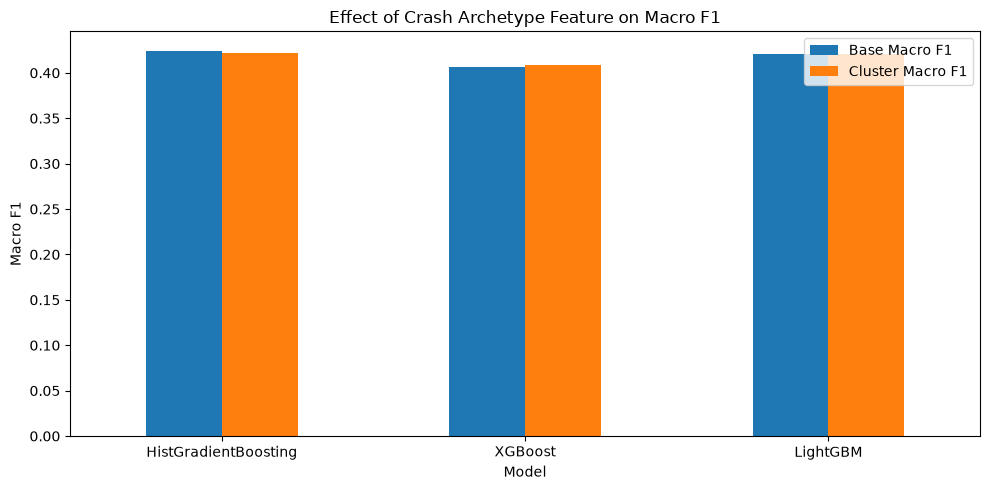

In [12]:
plot_df = comparison_df[
    ["Model", "Base Macro F1", "Cluster Macro F1"]
].set_index("Model")

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_xlabel("Model")
ax.set_ylabel("Macro F1")
ax.set_title("Effect of Crash Archetype Feature on Macro F1")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Fatal-Class Performance

The previous models struggled with the minority Fatal class, so Fatal precision, recall, and F1 are inspected separately after adding the archetype feature.

In [13]:
fatal_rows = []

for model_name, data in cluster_predictions.items():
    report = classification_report(
        y_test,
        data["pred"],
        target_names=["Fatal", "Other Injury", "Serious Injury"],
        output_dict=True,
        zero_division=0
    )

    fatal_rows.append({
        "Model": model_name,
        "Fatal Precision": report["Fatal"]["precision"],
        "Fatal Recall": report["Fatal"]["recall"],
        "Fatal F1": report["Fatal"]["f1-score"],
        "Fatal Support": report["Fatal"]["support"]
    })

fatal_results_df = pd.DataFrame(fatal_rows)
display(fatal_results_df.round(4))

,Model,Fatal Precision,Fatal Recall,Fatal F1,Fatal Support
0,HistGradientBoosting,0.6667,0.0060,0.0118,670.0
1,XGBoost,1.0000,0.0015,0.0030,670.0
2,LightGBM,0.7143,0.0075,0.0148,670.0


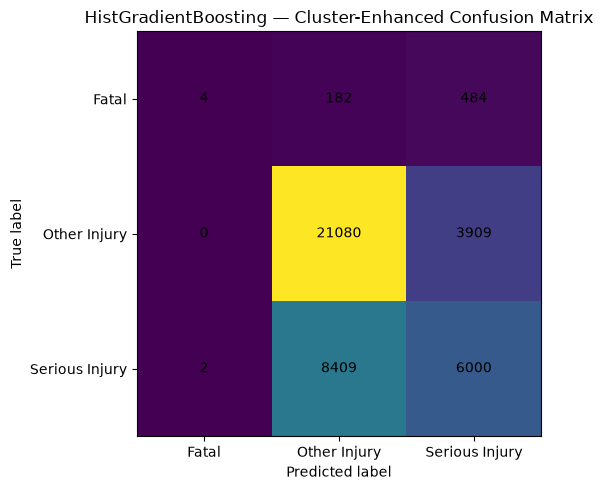

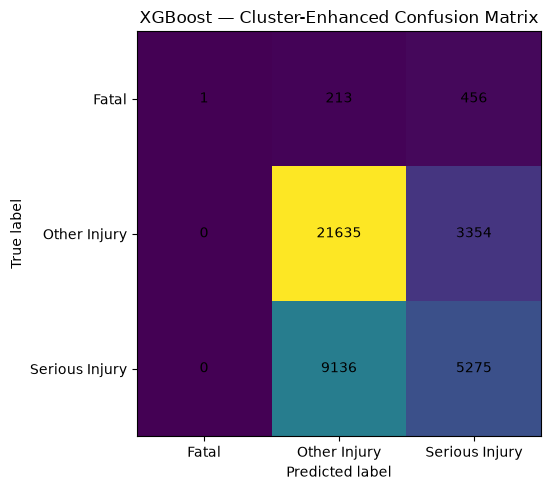

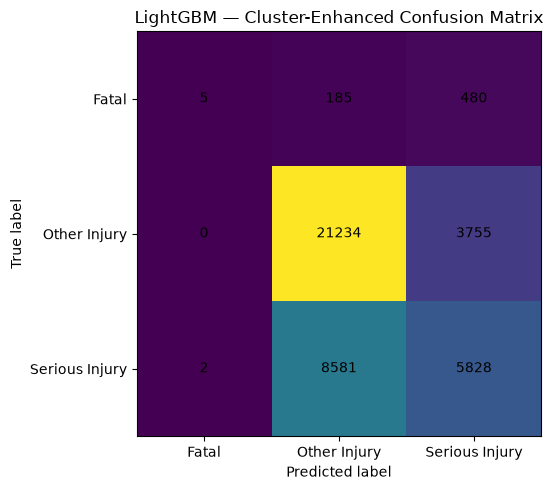

In [14]:
for model_name, data in cluster_predictions.items():
    cm = confusion_matrix(y_test, data["pred"])

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(cm)

    ax.set_title(
        f"{model_name} — Cluster-Enhanced Confusion Matrix"
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    labels = ["Fatal", "Other Injury", "Serious Injury"]
    ax.set_xticks(range(3), labels)
    ax.set_yticks(range(3), labels)

    for i in range(3):
        for j in range(3):
            ax.text(
                j, i, cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

## Interpretation

The cluster feature is considered useful only if the measured evaluation results improve.

If performance improves, the result supports the hypothesis that unsupervised crash archetypes capture latent structure useful for severity prediction.

If performance does not improve, the clusters still provide descriptive crash-pattern information, but the archetype feature does not add enough predictive information for the held-out severity task.

Do not claim improvement unless the measured metrics support it.

In [15]:
comparison_df.to_csv(
    os.path.join(DATA_DIR, "cluster_feature_model_comparison.csv"),
    index=False
)

cluster_results_df.to_csv(
    os.path.join(DATA_DIR, "cluster_enhanced_model_results.csv"),
    index=False
)

fatal_results_df.to_csv(
    os.path.join(DATA_DIR, "cluster_enhanced_fatal_results.csv"),
    index=False
)

print("Saved:")
print("- cluster_feature_model_comparison.csv")
print("- cluster_enhanced_model_results.csv")
print("- cluster_enhanced_fatal_results.csv")

Saved:
- cluster_feature_model_comparison.csv
- cluster_enhanced_model_results.csv
- cluster_enhanced_fatal_results.csv
